## Bloque 1. Importar librerías

En este bloque cargamos las librerías necesarias para:
- trabajar con arreglos numéricos
- crear gráficas
- usar el clasificador KNN
- cargar el dataset Iris


In [ ]:
# BLOQUE 1: IMPORTAR LIBRERÍAS
  
# NumPy se usa para operaciones numéricas y manejo de arreglos.
import numpy as np

# Matplotlib se usa para crear visualizaciones.
import matplotlib.pyplot as plt

# KNeighborsClassifier es la implementación del algoritmo KNN.
from sklearn.neighbors import KNeighborsClassifier as kNN

# load_iris carga el dataset Iris desde scikit-learn.
from sklearn.datasets import load_iris


### Interpretación del bloque 1

Este bloque no genera una salida visible compleja, pero es fundamental porque prepara todo el entorno de trabajo.

**Qué debe entender el estudiante aquí:**
- Ningún modelo de Machine Learning se puede entrenar sin primero cargar herramientas adecuadas.
- Cada librería cumple una función específica: cálculo, visualización, modelado y acceso a datos.
- Desde este punto ya están listas las bases para cargar, analizar y modelar el problema.


## Bloque 2. Cargar el dataset y separar variables

Aquí cargamos el dataset **Iris** y separamos:
- `iris_X`: variables de entrada
- `iris_y`: clases

Además seleccionamos solo dos variables para poder trabajar en un plano bidimensional.


In [2]:
# BLOQUE 2: CARGAR EL DATASET

# Cargamos el dataset completo.
iris = load_iris()

# Seleccionamos solo las dos primeras variables para poder visualizar en 2D.
iris_X = iris.data[:, 0:2]

# Guardamos las clases reales.
iris_y = iris.target

# Mostramos dimensiones.
print("Shape de iris_X:", iris_X.shape)
print("Shape de iris_y:", iris_y.shape)

# Mostramos nombres de clases y variables.
print("Nombres de las clases:", iris.target_names)
print("Nombres de las variables:", iris.feature_names)


Shape de iris_X: (150, 2)
Shape de iris_y: (150,)
Nombres de las clases: ['setosa' 'versicolor' 'virginica']
Nombres de las variables: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### Interpretación del bloque 2

La salida de este bloque normalmente muestra algo como:

- `iris_X` con forma `(150, 2)`
- `iris_y` con forma `(150,)`

**¿Qué significa esto?**
- Hay **150 observaciones** o flores.
- Cada flor se está describiendo con **2 características**.
- Existe una **etiqueta de clase** para cada flor.

**Valor pedagógico:**
- Este bloque ayuda a que el estudiante comprenda que un problema supervisado siempre tiene una estructura de entrada (`X`) y salida (`y`).
- También evidencia que el dataset original tenía más variables, pero aquí se redujo a dos por motivos de visualización.
- El uso de un dataset tan conocido como Iris permite concentrarse en la lógica del algoritmo y no en la limpieza de datos.


## Bloque 3. Visualizar los datos originales

Antes de entrenar el modelo, conviene observar la distribución de los datos.

La gráfica mostrará:
- cada flor como un punto
- cada especie como un color distinto
- dos variables del dataset como ejes


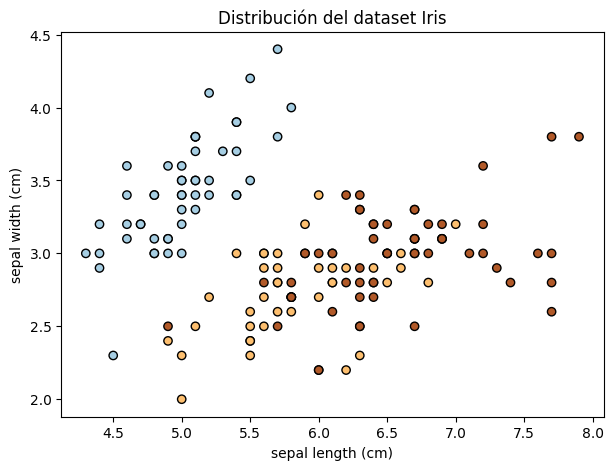

In [3]:
# BLOQUE 3: VISUALIZAR LOS DATOS

# Creamos figura y ejes.
_, ax = plt.subplots(figsize=(7, 5))

# Dibujamos la dispersión.
ax.scatter(
    iris_X[:, 0],
    iris_X[:, 1],
    c=iris_y,
    edgecolors='k',
    cmap='Paired'
)

# Agregamos contexto visual.
ax.set_title("Distribución del dataset Iris")
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])

# Mostramos la figura.
plt.show()


### Interpretación del bloque 3

Esta gráfica permite ver cómo están distribuidas las flores en el espacio de características.

**Qué debe observarse:**
- Si una clase aparece bien separada, será más fácil de clasificar.
- Si dos clases se superponen, el modelo tendrá más dificultad para diferenciarlas.
- El color ayuda a ver si el problema parece lineal o no lineal.

**Interpretación típica con Iris:**
- Usualmente una de las especies se separa bastante bien del resto.
- Otras dos especies pueden quedar más cercanas o solapadas parcialmente.
- Esto anticipa que KNN funcionará bien, pero no con la misma facilidad en todas las regiones del plano.

**Mensaje docente:**
Antes de entrenar un modelo, mirar los datos casi siempre da intuiciones valiosas sobre la dificultad del problema.


## Bloque 4. Crear y entrenar el modelo KNN

Aquí se construye el clasificador KNN con:
- `K = 7`
- distancia euclidiana

Luego se entrena con los datos de Iris.


In [4]:
# BLOQUE 4: CREAR Y ENTRENAR EL MODELO KNN

# Definimos K: número de vecinos.
n_neighbors = 7

# Creamos el modelo KNN.
knn = kNN(
    n_neighbors=n_neighbors,
    metric="euclidean"
)

# Entrenamos el modelo con datos y etiquetas.
knn.fit(iris_X, iris_y)

print("Modelo KNN entrenado correctamente")


Modelo KNN entrenado correctamente


### Interpretación del bloque 4

En este bloque el modelo queda listo para clasificar nuevos datos.

**Qué significa `K = 7`:**
- Cuando llegue una observación nueva, el algoritmo buscará sus **7 vecinos más cercanos**.
- La clase final se decidirá por mayoría entre esos vecinos.

**Qué significa “entrenar” en KNN:**
- A diferencia de otros algoritmos, KNN no ajusta una fórmula compleja.
- Su entrenamiento consiste principalmente en **guardar los datos y las etiquetas** para usarlos después al predecir.

**Interpretación didáctica:**
- KNN es ideal para enseñar clasificación porque la lógica de decisión es muy intuitiva.
- El valor de `K` es crucial: si es muy pequeño, el modelo puede volverse muy sensible; si es muy grande, puede perder detalle.


## Bloque 5. Crear una malla de puntos

Ahora construimos una malla sobre todo el plano para preguntarle al modelo qué clase asignaría en cada punto posible.

Esto permitirá visualizar las regiones del espacio que pertenecen a cada clase.


In [5]:
# BLOQUE 5: CREAR UNA MALLA DE PUNTOS

# Offset agrega margen visual alrededor de los datos.
offset = 0.5

# Límites del eje X.
x_min, x_max = iris_X[:, 0].min() - offset, iris_X[:, 0].max() + offset

# Límites del eje Y.
y_min, y_max = iris_X[:, 1].min() - offset, iris_X[:, 1].max() + offset

# Creamos una malla de 200x200 puntos.
x_grid, y_grid = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Convertimos la malla en una lista de puntos y predecimos su clase.
pred_grid = knn.predict(np.c_[x_grid.ravel(), y_grid.ravel()])

# Reorganizamos las predicciones para que coincidan con la forma de la malla.
pred_grid = pred_grid.reshape(x_grid.shape)

print("Shape de x_grid:", x_grid.shape)
print("Shape de y_grid:", y_grid.shape)
print("Shape de pred_grid:", pred_grid.shape)


Shape de x_grid: (200, 200)
Shape de y_grid: (200, 200)
Shape de pred_grid: (200, 200)


### Interpretación del bloque 5

Este bloque no analiza flores reales directamente; analiza **todo el espacio posible** en el plano.

**Qué significa la malla:**
- Cada punto de la malla representa una observación hipotética.
- El modelo decide qué clase tendría ese punto si existiera.

**Qué significan los tamaños mostrados:**
- `x_grid` y `y_grid` suelen tener forma `(200, 200)`.
- Eso significa que el plano fue dividido en **40.000 puntos**.
- `pred_grid` contiene la clase predicha para cada uno de esos puntos.

**Valor conceptual:**
- Aquí el estudiante ve que un clasificador no solo memoriza puntos, sino que **divide el espacio de entrada**.
- Esta idea es esencial para entender después las fronteras de decisión.


## Bloque 6. Visualizar las fronteras de decisión

En este bloque convertimos la malla y sus predicciones en una imagen:

- el fondo coloreado indica la clase predicha por el modelo
- los puntos reales muestran las observaciones del dataset


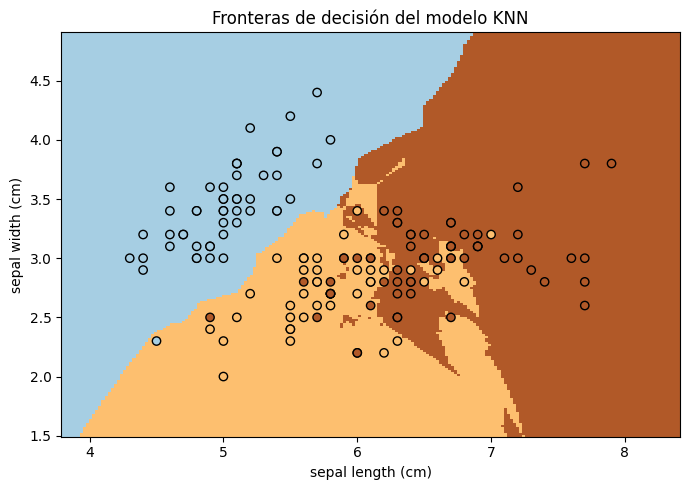

In [6]:
# BLOQUE 6: VISUALIZAR FRONTERAS DE DECISIÓN

# Creamos nueva figura.
_, ax = plt.subplots(figsize=(7, 5))

# Pintamos el fondo según la clase predicha.
ax.pcolormesh(
    x_grid,
    y_grid,
    pred_grid,
    cmap='Paired',
    shading='auto'
)

# Superponemos los puntos reales.
ax.scatter(
    iris_X[:, 0],
    iris_X[:, 1],
    c=iris_y,
    edgecolors='k',
    cmap='Paired'
)

# Agregamos etiquetas.
ax.set_title("Fronteras de decisión del modelo KNN")
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])

plt.tight_layout()
plt.show()


### Interpretación del bloque 6

Esta es una de las visualizaciones más importantes de toda la clase.

**Cómo leer la gráfica:**
- Cada región de color representa la clase que el modelo asignaría a un dato nuevo en esa zona.
- Los puntos reales permiten verificar si el modelo está alineado con la distribución observada.
- Los límites entre colores son las **fronteras de decisión**.

**Qué suele observarse con KNN:**
- Las fronteras pueden ser irregulares.
- Esa irregularidad refleja que KNN clasifica por cercanía local.
- Si `K` fuera menor, las fronteras serían más quebradas; si fuera mayor, serían más suaves.

**Conclusión didáctica:**
Esta gráfica muestra que KNN construye una lógica de clasificación espacial basada en vecindad.


## Bloque 7. Probar una predicción nueva

Finalmente, simulamos una nueva flor que el modelo no ha visto.

El modelo devolverá:
- la clase predicha
- el nombre de la especie
- las probabilidades por clase


In [7]:
# BLOQUE 7: PROBAR UNA PREDICCIÓN NUEVA

# Creamos una nueva observación.
nueva_flor = np.array([[5.8, 3.0]])

# Predecimos la clase.
prediccion = knn.predict(nueva_flor)[0]

# Obtenemos probabilidades por clase.
probabilidades = knn.predict_proba(nueva_flor)[0]

print("Nueva flor:", nueva_flor)
print("Clase predicha:", prediccion)
print("Nombre de la clase:", iris.target_names[prediccion])
print("Probabilidades por clase:")
for i, prob in enumerate(probabilidades):
    print(f"  {iris.target_names[i]}: {prob:.4f}")


Nueva flor: [[5.8 3. ]]
Clase predicha: 1
Nombre de la clase: versicolor
Probabilidades por clase:
  setosa: 0.0000
  versicolor: 0.7143
  virginica: 0.2857


### Interpretación del bloque 7

Este bloque traduce el modelo a una situación práctica: llega una flor nueva y queremos clasificarla.

**Cómo interpretar la salida:**
- La clase predicha es la que gana por mayoría entre los vecinos cercanos.
- Las probabilidades muestran qué tan repartidos estaban esos vecinos entre las clases.
- Una probabilidad muy alta para una sola clase indica una decisión más clara.
- Probabilidades más repartidas indican una zona de mayor ambigüedad.

**Valor docente:**
- Aquí el estudiante conecta la teoría con una decisión concreta.
- Es una excelente oportunidad para reforzar la idea de que KNN responde usando información local del vecindario.
